# Preprocessing

## Objective :
 This section transform raw data into clean , consistent and model ready format

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [116]:
#step1 - to change dtype of various columns
df["TotalCharges"]  = pd.to_numeric(df["TotalCharges"],errors = "coerce")
category_col  = df.select_dtypes(include = str).columns
df[category_col] = df[category_col].astype("category")
df["SeniorCitizen"] = df["SeniorCitizen"].astype("category")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   category
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 non-null   c

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler,PowerTransformer
df = df.drop("customerID",axis=1)
#removed unnecessary columns 
print(df.columns.tolist())
print(df.shape)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
(7043, 20)


<Axes: xlabel='TotalCharges', ylabel='Count'>

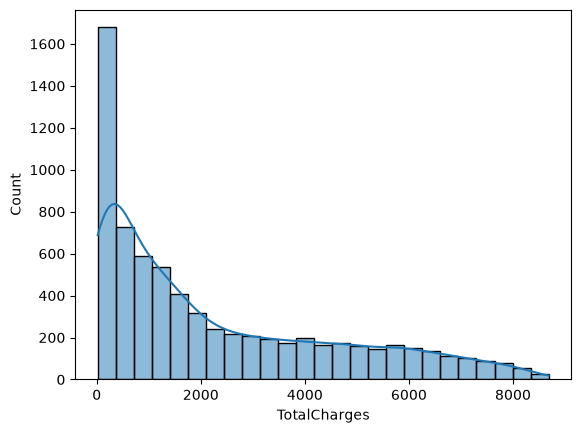

In [118]:
sns.histplot(df["TotalCharges"],kde=True)
#right skewed

In [119]:
numerical_col = df.select_dtypes(include = [float,int]).columns
print(df[numerical_col].skew())
# as you can see Total charges is right skewed and non negative - so will apply box-cox transform
category_col  = df.select_dtypes(include = str).columns
df[category_col] = df[category_col].astype("category")
print(df[numerical_col].isnull().sum())
print(df[category_col].isnull().sum())

#only 11 missing value


tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64
tenure             0
MonthlyCharges     0
TotalCharges      11
dtype: int64
Series([], dtype: float64)


In [120]:
X = df.drop("Churn",axis = 1)
y = df["Churn"]
X_train ,X_test, y_train, y_test  = train_test_split(X,y,test_size=0.2,random_state=42,stratify = y)

imputer = SimpleImputer(strategy="median")
X_train["TotalCharges"] = imputer.fit_transform(
    X_train[["TotalCharges"]]
)

X_test["TotalCharges"] = imputer.transform(
    X_test[["TotalCharges"]]
)
# Handling of missing values
numerical_col = X_train.select_dtypes(include="number").columns
category_col = X_train.select_dtypes(include="category").columns


In [121]:
num_pipeline = Pipeline([("imputer_1",SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler())
])
category_pipeline = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))])


In [122]:
print(type(X_train))

<class 'pandas.DataFrame'>


In [123]:
preprocessor = ColumnTransformer([("num",num_pipeline,numerical_col),("cat",category_pipeline,category_col)])
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [127]:
import os


# Create DataFrames with feature names
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

# Reset target indices
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Create processed folder if it doesn't exist
os.makedirs("../data/processed", exist_ok=True)

# Save processed datasets
X_train_processed_df.to_csv(
    "../data/processed/X_train_processed.csv",
    index=False
)

X_test_processed_df.to_csv(
    "../data/processed/X_test_processed.csv",
    index=False
)

y_train.to_csv(
    "../data/processed/y_train.csv",
    index=False
)

y_test.to_csv(
    "../data/processed/y_test.csv",
    index=False
)